### IMPORT LIBRARIES

In [1]:
import json
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict, Counter

### LOAD DATA

In [ ]:

ANNOTATED_FOLDER = "/kaggle/input/annotated/Annotated"  # Folder with prev/next format
# ANNOTATED_MINUS_1_FOLDER = "/kaggle/input/annotated-with-negative-1/Annotated_Processed"  # Folder with prev-1/prev format

OUTPUT_DIR = "/kaggle/working"
COMBINED_JSONL = f"{OUTPUT_DIR}/combined_clauses.jsonl"  # prev/current/next format
# COMBINED_PREV_JSONL = f"{OUTPUT_DIR}/combined_clauses_prev.jsonl"  # prev-1/prev/current format

# Split configuration
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ======================================================================
# LOAD AND COMBINE DATA FROM ANNOTATED FOLDER (prev/current/next format)
# ======================================================================

def load_annotated_folder(folder_path, use_prev_minus_one=False):
    """
    Load all JSON files from folder and convert to JSONL format.

    Args:
        folder_path: Path to folder containing JSON files
        use_prev_minus_one: If True, use prev_minus_1_clause; else use next_clause

    Returns:
        List of dictionaries, one per clause
    """
    all_clauses = []
    count_docs = 0
    count_clauses = 0

    # Walk through all subdirectories
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.endswith(".json"):
                filepath = os.path.join(root, filename)
                try:
                    with open(filepath, "r", encoding="utf-8") as f:
                        data = json.load(f)

                    if "doc_id" not in data or "clauses" not in data:
                        continue

                    doc_id = data["doc_id"]

                    for clause in data["clauses"]:
                        if "text" not in clause or "label" not in clause:
                            continue

                        entry = {
                            "doc_id": doc_id,
                            "clause_id": clause.get("clause_id", 0),
                            "text": clause.get("text", ""),
                            "label": clause.get("label", "None"),
                        }

                        if use_prev_minus_one:
                            # For Annotated_minus_1 folder
                            entry["prev_text"] = clause.get("prev_clause")
                            entry["prev_text_1"] = clause.get("prev_minus_1_clause")
                        else:
                            # For Annotated folder
                            entry["prev_text"] = clause.get("prev_clause")
                            entry["next_text"] = clause.get("next_clause")

                        all_clauses.append(entry)
                        count_clauses += 1

                    count_docs += 1

                except json.JSONDecodeError as e:
                    print(f"⚠️ Error decoding {filepath}: {e}")
                    continue
                except Exception as e:
                    print(f"⚠️ Error processing {filepath}: {e}")
                    continue

    print(f"Loaded {count_docs} documents, {count_clauses} clauses from {folder_path}")
    return all_clauses

# Load from both folders
print("Loading data from Annotated folder (prev/current/next format)...")
clauses_annotated = load_annotated_folder(ANNOTATED_FOLDER, use_prev_minus_one=False)

# print("\nLoading data from Annotated_minus_1 folder (prev-1/prev/current format)...")
# clauses_prev = load_annotated_folder(ANNOTATED_MINUS_1_FOLDER, use_prev_minus_one=True)

print(f"\nTotal clauses loaded:")
print(f"  From Annotated: {len(clauses_annotated)}")
# print(f"  From Annotated_minus_1: {len(clauses_prev)}")

# ========================
# CHECK LABEL DISTRIBUTION
# ========================

def print_label_distribution(clauses, name):
    """Print label distribution for a set of clauses."""
    label_counts = Counter(clause["label"] for clause in clauses)
    total = len(clauses)

    print(f"\n{name} Label Distribution:")
    print(f"Total: {total} clauses")
    for label, count in sorted(label_counts.items()):
        print(f"  {label}: {count} ({100*count/total:.2f}%)")

print_label_distribution(clauses_annotated, "Annotated folder")
# print_label_distribution(clauses_prev, "Annotated_minus_1 folder")

# ==========================
# SAVE COMBINED JSONL FILES
# ==========================

def save_jsonl(filepath, clauses):
    """Save clauses to JSONL file."""
    with open(filepath, "w", encoding="utf-8") as f:
        for clause in clauses:
            json.dump(clause, f, ensure_ascii=False)
            f.write("\n")
    print(f"✓ Saved {len(clauses)} clauses to {filepath}")

# Save combined files
print("Saving combined JSONL files...")
save_jsonl(COMBINED_JSONL, clauses_annotated)
# save_jsonl(COMBINED_PREV_JSONL, clauses_prev)

print(f"\n✓ Combined files saved:")
print(f"  {COMBINED_JSONL} (prev/current/next format)")
# print(f"  {COMBINED_PREV_JSONL} (prev-1/prev/current format)")

Loading data from Annotated folder (prev/current/next format)...
Loaded 100 documents, 12631 clauses from /kaggle/input/annotated/Annotated

Total clauses loaded:
  From Annotated: 12631

Annotated folder Label Distribution:
Total: 12631 clauses
  Claim: 1893 (14.99%)
  None: 4232 (33.50%)
  Opposition: 512 (4.05%)
  Premise: 5994 (47.45%)
Saving combined JSONL files...
✓ Saved 12631 clauses to /kaggle/working/combined_clauses.jsonl

✓ Combined files saved:
  /kaggle/working/combined_clauses.jsonl (prev/current/next format)


### SPLIT INTO TRAIN/VAL/TEST (Document-level split to avoid data leakage)

In [ ]:
def split_by_documents(clauses, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    """
    Split clauses by document to avoid data leakage.
    Ensures clauses from the same document stay together.
    """
    random.seed(seed)

    # Group clauses by document
    docs_to_clauses = defaultdict(list)
    for clause in clauses:
        doc_id = clause["doc_id"]
        docs_to_clauses[doc_id].append(clause)

    # Get list of document IDs
    doc_ids = list(docs_to_clauses.keys())
    random.shuffle(doc_ids)

    total_docs = len(doc_ids)
    train_end = int(total_docs * train_ratio)
    val_end = train_end + int(total_docs * val_ratio)

    # Split documents
    train_docs = doc_ids[:train_end]
    val_docs = doc_ids[train_end:val_end]
    test_docs = doc_ids[val_end:]

    train_clauses = []
    val_clauses = []
    test_clauses = []

    for doc_id in train_docs:
        train_clauses.extend(docs_to_clauses[doc_id])

    for doc_id in val_docs:
        val_clauses.extend(docs_to_clauses[doc_id])

    for doc_id in test_docs:
        test_clauses.extend(docs_to_clauses[doc_id])

    # Shuffle clauses within each split
    random.shuffle(train_clauses)
    random.shuffle(val_clauses)
    random.shuffle(test_clauses)

    return train_clauses, val_clauses, test_clauses, train_docs, val_docs, test_docs

# Split the data
print("Splitting data into train/val/test (document-level split)...")
train_clauses, val_clauses, test_clauses, train_docs, val_docs, test_docs = split_by_documents(
    # clauses_prev,
    clauses_annotated,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED
)

print(f"\nSplit Summary:")
print(f"  Documents - Train: {len(train_docs)}, Val: {len(val_docs)}, Test: {len(test_docs)}")
print(f"  Clauses - Train: {len(train_clauses)}, Val: {len(val_clauses)}, Test: {len(test_clauses)}")
print(f"  Total: {len(train_clauses) + len(val_clauses) + len(test_clauses)} clauses")

Splitting data into train/val/test (document-level split)...

Split Summary:
  Documents - Train: 70, Val: 15, Test: 15
  Clauses - Train: 8020, Val: 2991, Test: 1620
  Total: 12631 clauses


### CREATE CORRESPONDING SPLITS FOR PREV_MINUS_1 FORMAT

In [ ]:
# # Create a mapping from (doc_id, clause_id) to clause for prev format
# prev_clause_map = {}
# for clause in clauses_prev:
#     key = (clause["doc_id"], clause["clause_id"])
#     prev_clause_map[key] = clause

# train_clauses_prev = []
# val_clauses_prev = []
# test_clauses_prev = []

# for clause in train_clauses:
#     key = (clause["doc_id"], clause["clause_id"])
#     if key in prev_clause_map:
#         train_clauses_prev.append(prev_clause_map[key])

# for clause in val_clauses:
#     key = (clause["doc_id"], clause["clause_id"])
#     if key in prev_clause_map:
#         val_clauses_prev.append(prev_clause_map[key])

# for clause in test_clauses:
#     key = (clause["doc_id"], clause["clause_id"])
#     if key in prev_clause_map:
#         test_clauses_prev.append(prev_clause_map[key])

# print(f"Created corresponding splits for prev_minus_1 format:")
# print(f"  Train: {len(train_clauses_prev)}, Val: {len(val_clauses_prev)}, Test: {len(test_clauses_prev)}")

# ===========================
# SAVE TRAIN/VAL/TEST SPLITS
# ===========================

# # Save splits for prev/current/next format
save_jsonl(f"{OUTPUT_DIR}/train.jsonl", train_clauses)
save_jsonl(f"{OUTPUT_DIR}/val.jsonl", val_clauses)
save_jsonl(f"{OUTPUT_DIR}/test.jsonl", test_clauses)

# Save splits for prev-1/prev/current format
# save_jsonl(f"{OUTPUT_DIR}/train_prev.jsonl", train_clauses_prev)
# save_jsonl(f"{OUTPUT_DIR}/val_prev.jsonl", val_clauses_prev)
# save_jsonl(f"{OUTPUT_DIR}/test_prev.jsonl", test_clauses_prev)

print(f"\n✓ All splits saved to {OUTPUT_DIR}/")
print(f"\nFiles created:")
print(f"  For prev/current/next format:")
print(f"    - train.jsonl ({len(train_clauses)} clauses)")
print(f"    - val.jsonl ({len(val_clauses)} clauses)")
print(f"    - test.jsonl ({len(test_clauses)} clauses)")
# print(f"  For prev-1/prev/current format:")
# print(f"    - train_prev.jsonl ({len(train_clauses_prev)} clauses)")
# print(f"    - val_prev.jsonl ({len(val_clauses_prev)} clauses)")
# print(f"    - test_prev.jsonl ({len(test_clauses_prev)} clauses)")

✓ Saved 8020 clauses to /kaggle/working/train.jsonl
✓ Saved 2991 clauses to /kaggle/working/val.jsonl
✓ Saved 1620 clauses to /kaggle/working/test.jsonl

✓ All splits saved to /kaggle/working/

Files created:
  For prev/current/next format:
    - train.jsonl (8020 clauses)
    - val.jsonl (2991 clauses)
    - test.jsonl (1620 clauses)


### CLAUSE CLASSIFICATION TRAINING

In [ ]:
import json
import random
import numpy as np
from collections import Counter
import torch
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import load_dataset, concatenate_datasets
from sklearn.metrics import classification_report, confusion_matrix

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

2026-01-24 05:05:15.720516: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769231115.741798    2304 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769231115.748312    2304 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

### CONFIGURATIONS

In [ ]:
# MODEL_NAME = "nlpaueb/legal-bert-base-uncased"
MODEL_NAME = "law-ai/InCaseLawBERT"
# MODEL_NAME = "law-ai/InLegalBERT"
# MODEL_NAME = "Saibo-creator/legal-roberta-base"


MAX_LEN = 512
OUTPUT_DIR = "./model_out_anti_overfit"
BATCH_SIZE = 8
NUM_EPOCHS = 15
LEARNING_RATE = 2e-5
EARLY_STOPPING_PATIENCE = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LABEL2ID = {"Premise": 0, "None": 1, "Opposition": 2, "Claim": 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

print(f"Device: {DEVICE}")
print(f"Model: {MODEL_NAME}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Early Stopping Patience: {EARLY_STOPPING_PATIENCE} epochs")

Device: cuda
Model: law-ai/InCaseLawBERT
Learning Rate: 2e-05
Early Stopping Patience: 3 epochs


### CONFIGURATIONS

In [ ]:
dataset = load_dataset("json", data_files={
    "train": "train.jsonl",
    "validation": "val.jsonl",
    "test": "test.jsonl"
})

print("Dataset loaded:")
print(f"Train: {len(dataset['train'])} samples")
print(f"Validation: {len(dataset['validation'])} samples")
print(f"Test: {len(dataset['test'])} samples")

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset loaded:
Train: 8020 samples
Validation: 2991 samples
Test: 1620 samples


### TOKENIZATION FUNCTION

In [ ]:
# =============
# Encode Labels
# =============
def encode_labels(example):
    example["labels"] = LABEL2ID[example["label"]]
    return example

dataset = dataset.map(encode_labels)

# =====================
# Initialize Tokenizer
# =====================
print(f"Loading tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    """Tokenize text with context from prev_text and next_text"""
    texts = []
    for i in range(len(batch["text"])):
        text = batch["text"][i]
        prev = batch.get("prev_text", [None] * len(batch["text"]))[i]
        # prev_1 = batch.get("prev_text_1", [None] * len(batch["text"]))[i]
        next_text = batch.get("next_text", [None] * len(batch["text"]))[i]

        # Build context string
        context_parts = []
        # if prev_1 and prev_1.strip():
        #     context_parts.append(f"[PREV_1] {prev_1.strip()}")
        if prev and prev.strip():
            context_parts.append(f"[PREV] {prev.strip()}")
        context_parts.append(f"[CURRENT] {text.strip()}")
        if next_text and next_text.strip():
            context_parts.append(f"[NEXT] {next_text.strip()}")


        texts.append(" ".join(context_parts))

    return tokenizer(texts, truncation=True, padding="max_length", max_length=MAX_LEN)

print("Tokenizing datasets...")
tokenized_datasets = dataset.map(tokenize_fn, batched=True)

# Remove unnecessary columns
columns_to_remove = ["label", "doc_id", "clause_id"]
for col in columns_to_remove:
    if col in tokenized_datasets["train"].column_names:
        tokenized_datasets = tokenized_datasets.remove_columns([col])

# Set PyTorch format
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("✅ Tokenization complete")

Map:   0%|          | 0/8020 [00:00<?, ? examples/s]

Map:   0%|          | 0/2991 [00:00<?, ? examples/s]

Map:   0%|          | 0/1620 [00:00<?, ? examples/s]

Loading tokenizer for law-ai/InCaseLawBERT...
Tokenizing datasets...


Map:   0%|          | 0/8020 [00:00<?, ? examples/s]

Map:   0%|          | 0/2991 [00:00<?, ? examples/s]

Map:   0%|          | 0/1620 [00:00<?, ? examples/s]

✅ Tokenization complete


### COMPUTE CLASS WEIGHTS FOR IMBALANCED DATA

In [ ]:
train_labels = [x["labels"].item() for x in tokenized_datasets["train"]]
label_counts = Counter(train_labels)
total = sum(label_counts.values())
num_classes = len(label_counts)

class_weights = torch.tensor(
    [total / (num_classes * label_counts[i]) for i in range(num_classes)],
    dtype=torch.float
)

with open("class_weights.json", "w") as f:
    json.dump({ID2LABEL[i]: w.item() for i, w in enumerate(class_weights)}, f, indent=4)

print("Label counts:", label_counts)
print("Class weights:", {ID2LABEL[i]: w.item() for i, w in enumerate(class_weights)})

Label counts: Counter({0: 3728, 1: 2677, 3: 1297, 2: 318})
Class weights: {'Premise': 0.537821888923645, 'None': 0.7489727139472961, 'Opposition': 6.3050312995910645, 'Claim': 1.545875072479248}


### INITIALIZE MODEL

In [ ]:
print(f"Loading model: {MODEL_NAME}...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3
)
model.to(DEVICE)
print("✅ Model loaded")

Loading model: law-ai/InCaseLawBERT...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at law-ai/InCaseLawBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded


### WEIGHTED TRAINER & COMPUTE METRICS

In [ ]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    report = classification_report(labels, preds, target_names=LABEL2ID.keys(), output_dict=True, zero_division=0)

    metrics = {
        "f1_macro": report["macro avg"]["f1-score"],
        "precision_macro": report["macro avg"]["precision"],
        "recall_macro": report["macro avg"]["recall"],
        "accuracy": report["accuracy"]
    }

    # Add per-class F1 scores
    for label_name in LABEL2ID.keys():
        if label_name in report:
            metrics[f"{label_name}_f1"] = report[label_name]["f1-score"]

    return metrics

### TRAINING ARGUMENTS

In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    gradient_accumulation_steps=2,

    # Learning rate and scheduling
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,

    # Regularization
    weight_decay=0.1,
    max_grad_norm=1.0,

    # Evaluation and saving
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,
    save_total_limit=3,

    # Reproducibility
    seed=SEED,
    data_seed=SEED,

    # Other settings
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
)

print("✅ Training arguments configured with anti-overfitting measures:")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Weight Decay: {training_args.weight_decay}")
print(f"  - Max Grad Norm: {training_args.max_grad_norm}")
print(f"  - LR Scheduler: {training_args.lr_scheduler_type}")
print(f"  - Early Stopping Patience: {EARLY_STOPPING_PATIENCE} epochs")

✅ Training arguments configured with anti-overfitting measures:
  - Learning Rate: 2e-05
  - Weight Decay: 0.1
  - Max Grad Norm: 1.0
  - LR Scheduler: SchedulerType.COSINE
  - Early Stopping Patience: 3 epochs


### INITIALIZE TRAINER WITH EARLY STOPPING

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)
    ]
)

print("✅ Trainer initialized with early stopping callback")

✅ Trainer initialized with early stopping callback


### TRAIN MODEL

In [ ]:
print("🚀 Starting training...")
print("=" * 60)
trainer.train()
print("=" * 60)
print("✅ Training complete!")

🚀 Starting training...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,F1 Macro,Precision Macro,Recall Macro,Accuracy,Premise F1,None F1,Opposition F1,Claim F1
1,1.254200,1.248683,0.455261,0.492909,0.507083,0.604146,0.672835,0.662084,0.050000,0.436127
2,0.966700,1.001458,0.536753,0.528209,0.602908,0.625209,0.671007,0.708245,0.260241,0.507519
3,0.771300,0.985654,0.536921,0.530123,0.626644,0.607823,0.628895,0.713919,0.302128,0.502742
4,0.721400,1.048123,0.554859,0.545576,0.613286,0.637245,0.654063,0.715012,0.319018,0.531343
5,0.544500,1.233233,0.580668,0.583670,0.604000,0.693414,0.739333,0.735193,0.283262,0.564885
6,0.495800,1.274608,0.582668,0.573588,0.609735,0.689736,0.732973,0.735093,0.292135,0.570470
7,0.486000,1.396988,0.572616,0.576236,0.591604,0.699097,0.748135,0.734812,0.232143,0.575374
8,0.363000,1.693174,0.545374,0.558893,0.577196,0.679706,0.718101,0.729642,0.170854,0.562900
9,0.358700,1.769651,0.556241,0.577524,0.574799,0.700435,0.745364,0.733612,0.159574,0.586412


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

✅ Training complete!


### PLOT PROGRESS

In [ ]:
# Extract log history
logs = trainer.state.log_history

train_loss = []
eval_loss = []
eval_accuracy = []
eval_f1 = []
epochs_train = []
epochs_eval = []

for log in logs:
    # Training loss logs
    if "loss" in log and "epoch" in log and "eval_loss" not in log:
        train_loss.append(log["loss"])
        epochs_train.append(log["epoch"])

    # Evaluation logs
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        eval_accuracy.append(log.get("eval_accuracy"))
        eval_f1.append(log.get("eval_f1_macro"))
        epochs_eval.append(log["epoch"])

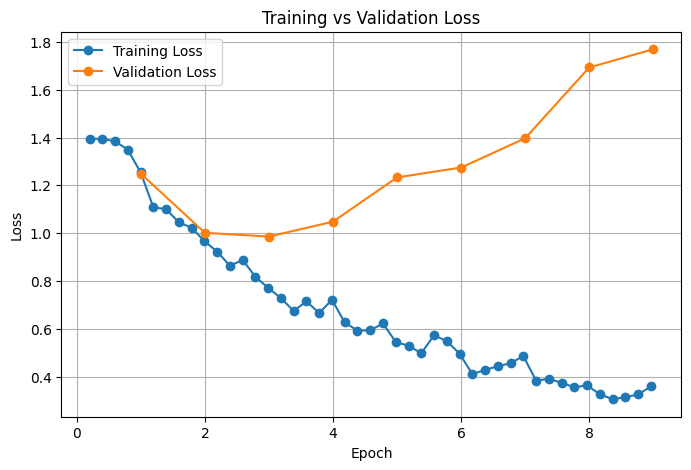

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_train, train_loss, label="Training Loss", marker="o")
plt.plot(epochs_eval, eval_loss, label="Validation Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

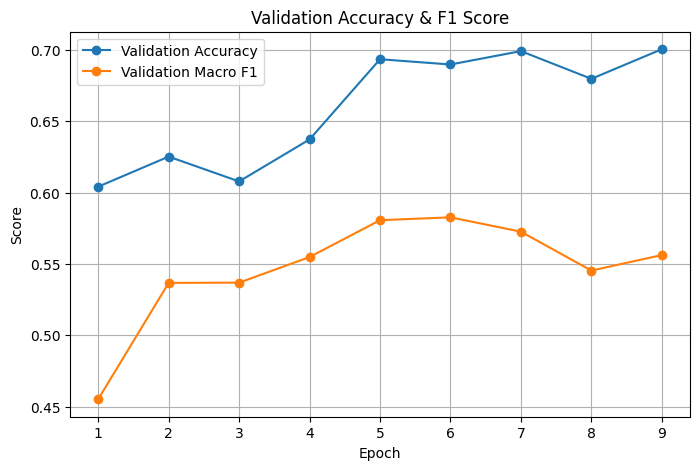

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_eval, eval_accuracy, label="Validation Accuracy", marker="o")
plt.plot(epochs_eval, eval_f1, label="Validation Macro F1", marker="o")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Accuracy & F1 Score")
plt.legend()
plt.grid(True)
plt.show()

### EVALUATE ON TEST SET

In [ ]:
print("\n📊 Evaluating on test set...")
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("\n" + "=" * 60)
print("TEST SET METRICS:")
print("=" * 60)
for key, value in test_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

# Save test metrics
with open("test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=4)
print("\n✅ Test metrics saved to test_metrics.json")


📊 Evaluating on test set...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



TEST SET METRICS:
eval_loss: 0.9056
eval_f1_macro: 0.6803
eval_precision_macro: 0.6848
eval_recall_macro: 0.6917
eval_accuracy: 0.7296
eval_Premise_f1: 0.7380
eval_None_f1: 0.7688
eval_Opposition_f1: 0.5567
eval_Claim_f1: 0.6575
eval_runtime: 27.5154
eval_samples_per_second: 58.8760
eval_steps_per_second: 1.8540
epoch: 9.0000

✅ Test metrics saved to test_metrics.json


### DETAILED CLASSIFICATION REPORT

In [ ]:
print("\n📈 Generating detailed classification report...")

predictions = trainer.predict(tokenized_datasets["test"])
y_pred = predictions.predictions.argmax(-1)
y_true = predictions.label_ids

# Generate detailed report
report = classification_report(
    y_true,
    y_pred,
    target_names=list(LABEL2ID.keys()),
    output_dict=False
)

print("\n" + "=" * 60)
print("DETAILED CLASSIFICATION REPORT:")
print("=" * 60)
print(report)

# Save detailed report
with open("classification_report.txt", "w") as f:
    f.write(report)

print("\n✅ Detailed report saved to classification_report.txt")


📈 Generating detailed classification report...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Premise       0.83      0.67      0.74       750
        None       0.73      0.81      0.77       572
  Opposition       0.61      0.51      0.56        53
       Claim       0.57      0.78      0.66       245

    accuracy                           0.73      1620
   macro avg       0.68      0.69      0.68      1620
weighted avg       0.75      0.73      0.73      1620


✅ Detailed report saved to classification_report.txt


### SAVE FINAL MODEL

In [ ]:
final_model_path = "./final_model"
print(f"\n💾 Saving final model to {final_model_path}...")
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)
print("✅ Model and tokenizer saved!")


💾 Saving final model to ./final_model...
✅ Model and tokenizer saved!


In [21]:
!zip "/kaggle/working/InCaseLawBert.zip" -r "/kaggle/working/final_model"

  adding: kaggle/working/final_model/ (stored 0%)
  adding: kaggle/working/final_model/vocab.txt (deflated 53%)
  adding: kaggle/working/final_model/tokenizer_config.json (deflated 74%)
  adding: kaggle/working/final_model/training_args.bin (deflated 52%)
  adding: kaggle/working/final_model/special_tokens_map.json (deflated 42%)
  adding: kaggle/working/final_model/model.safetensors

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 8%)
  adding: kaggle/working/final_model/tokenizer.json (deflated 71%)
  adding: kaggle/working/final_model/config.json (deflated 55%)
